In [10]:
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

def pearson_spearman(x, y):
    pearson_corr, pearson_p_value = scipy.stats.pearsonr(x, y)
    print(f"Pearson correlation coefficient: {pearson_corr:.4f}, p-value: {pearson_p_value:.4g}")

    spearman_corr, spearman_p_value = scipy.stats.spearmanr(x, y)
    print(f"Spearman correlation coefficient: {spearman_corr:.4f}, p-value: {spearman_p_value:.4g}")

species_list = ['newRat']

def mean_squared_error(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return np.mean((x - y) ** 2)

def format_value(metric_name, value):
    """Format values depending on whether it's a P-value metric or not."""
    # Check for '_p' which is more general for 'pearson_p', 'spearman_p' etc.
    if "_p" in metric_name:
        return f"{value:.2e}"  # Scientific notation for p-values
    else:
        return f"{value:.3g}"  # General format for other metrics

In [11]:
# 1 3 5 LOG MODELS
import pandas as pd
import scipy.stats

def correlate(mhc):
    rows = []
    # Lists for correlation calculations
    groups = ['Test','Test2', 'Test3']
    preds = [pred_testPos, pred_test2_df, pred_test3_df]
    trues = [doubled_testPos, doubled_test2_df, doubled_test3_df]

    # Calculate correlations
    for group, pred_df, true_df in zip(groups, preds, trues):
        x = true_df.squeeze()
        y = pred_df.squeeze()
        pearson, pearson_p = scipy.stats.pearsonr(x, y)
        spearman, spearman_p = scipy.stats.spearmanr(x, y)
        mse = mean_squared_error(x, y)
        pearson_p *= mhc
        spearman_p *= mhc
        
        rows.append({'Group': group, 'Metric': 'Pearson', 'Value': pearson})
        rows.append({'Group': group, 'Metric': 'Pearson_p', 'Value': pearson_p})
        rows.append({'Group': group, 'Metric': 'Spearman', 'Value': spearman})
        rows.append({'Group': group, 'Metric': 'Spearman_p', 'Value': spearman_p})
        rows.append({'Group': group, 'Metric': 'MSE', 'Value': mse})
          
    return pd.DataFrame(rows)

def negatives():
    rows = []
     # Lists for negative average calculations
    negGroup = ['Test neg', 'Test1 avg pred']
    negValues = [pred_testNeg.mean().iloc[0], pred_test1_df.mean().iloc[0]]
    
    # Add negative value averages
    for group, negv in zip(negGroup, negValues):
        rows.append({'Group': group, 'Metric': 'Avg Neg Prediction', 'Value': negv})

    return pd.DataFrame(rows)

mhc = 200

all_results = []
neg_results = []
model_list = ['bdbi7l3n', 'kf8188qf', 'p1bd3srf', 'cq45eb2s']

for species in species_list:
    print(species)
    for model in model_list:
        print(model)
        model_dir = f'{model}'

        if model == 'kf8188qf':
            mhc = 100
        
        #############################################################################

        # load TEST ORTHO DFs
        pred_TEST_ortho = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/model_outputs/{model_dir}/activations_{species}_TEST_pos_neg.csv', header=None)
        
        testPos = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_pos/{species}_liver_TEST_500bp.bed', header=None, delim_whitespace=True).iloc[:,4]
        testNeg = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/neg/{species}_liver_TEST_500bp.bed', header=None, delim_whitespace=True).iloc[:,4]
        
        testPos_len = 2*len(testPos)
        testNeg_len = 2*len(testNeg)
        
        if len(pred_TEST_ortho) != testPos_len+testNeg_len:
            print(f"ERROR TEST ORTHO ({species}, {model}): predictions are a different length than validation sets")
        doubled_testPos = pd.concat([testPos, testPos]).sort_index(kind='mergesort').reset_index(drop=True)
        doubled_testNeg = pd.concat([testNeg, testNeg]).sort_index(kind='mergesort').reset_index(drop=True)
        
        pred_testPos = pred_TEST_ortho.head(testPos_len)
        print(pred_testPos.mean())
        
        pred_testNeg = pred_TEST_ortho.tail(testNeg_len)

        #############################################################################
        # load TEST DFs
        pred_TEST = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/model_outputs/{model_dir}/activations_{species}_TEST.csv', header=None)
        
        test1_df = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/test1/{species}_liver_TEST_500bp.bed', header=None, delim_whitespace=True).iloc[:,4]
        test2_df = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed', header=None, delim_whitespace=True).iloc[:,4]
        test3_df = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test3/{species}_liver_TEST_500bp.bed', header=None, delim_whitespace=True).iloc[:,4]
        
        test1_len = 2*len(test1_df)
        test2_len = 2*len(test2_df)
        test3_len = 2*len(test3_df)
        
        if len(pred_TEST) != test1_len+test2_len+test3_len:
            print(f"ERROR TEST ({species}, {model}): predictions are a different length than validation sets")
        
        doubled_test1_df = pd.concat([test1_df, test1_df]).sort_index(kind='mergesort').reset_index(drop=True)
        doubled_test2_df = pd.concat([test2_df, test2_df]).sort_index(kind='mergesort').reset_index(drop=True)
        doubled_test3_df = pd.concat([test3_df, test3_df]).sort_index(kind='mergesort').reset_index(drop=True)
        
        pred_test1_df = pred_TEST.head(test1_len)
        pred_test2_df = pred_TEST.iloc[test1_len:test1_len + test2_len]
        pred_test3_df = pred_TEST.tail(test3_len)

        #############################################################################
        
        # Call the correlate function which now uses the globally available DFs
        corr_df = correlate(mhc)
        corr_df['species'] = species
        corr_df['model'] = model
        all_results.append(corr_df)

        neg_df = negatives()
        neg_df['species'] = species
        neg_df['model'] = model
        neg_results.append(neg_df)

# #############################################################################
# FINAL PROCESSING
# #############################################################################

summary_df = pd.concat(all_results)

summary_neg_df = pd.concat(neg_results)

# Define the custom order to place negative groups at the bottom.
custom_group_order = [
    'Test', 'Test2', 'Test3'
]

custom_group_order_neg = [
    'Test neg', 'Test1 avg pred'
]

# Convert 'group' to a categorical type with the specified order.
summary_df['Group'] = pd.Categorical(summary_df['Group'], categories=custom_group_order, ordered=True)
summary_neg_df['Group'] = pd.Categorical(summary_neg_df['Group'], categories=custom_group_order_neg, ordered=True)


# Pivot so each model is a column
pivot_df = summary_df.pivot_table(
    index=['species', 'Group', 'Metric'],
    columns='model',
    values='Value'
)

pivot_neg_df = summary_neg_df.pivot_table(
    index=['species', 'Group', 'Metric'],
    columns='model',
    values='Value'
)

# Sort the index to maintain a logical order (will now use the custom group order)
pivot_df = pivot_df.sort_index(level=['species', 'Group', 'Metric'])
pivot_neg_df = pivot_neg_df.sort_index(level=['species', 'Group', 'Metric'])

pivot_df_reordered = pivot_df[model_list]
pivot_neg_df_reordered = pivot_neg_df[model_list]

metric_vars = ['Pearson', 'Pearson_p', 'Spearman', 'Spearman_p', 'MSE']
pivot_df_reordered = pivot_df_reordered.reindex(metric_vars, level='Metric')

# Loop through each model's column to apply the formatting
for col in pivot_df_reordered.columns:
    pivot_df_reordered[col] = pivot_df_reordered.apply(
        # Access the 'metric' from the index using row.name[2]
        # (assuming it's the 3rd level of your index)
        lambda row: format_value(row.name[2], row[col]),
        axis=1)

display(pivot_df_reordered)

output_filename = '/home/azstephe/liverRegression/regression_liver/data/figs/tables/135log_model_eval_table_newRat_mse.tsv'
pivot_df_reordered.to_csv(output_filename, sep='\t', float_format='%.3f')

output_neg_filename = '/home/azstephe/liverRegression/regression_liver/data/figs/tables/135log_model_neg_table_newRat.tsv'
pivot_neg_df_reordered.to_csv(output_neg_filename, sep='\t', float_format='%.3f')

# print(f'Results successfully saved to: {output_filename}')

newRat
bdbi7l3n
0    0.910231
dtype: float64
kf8188qf
0    1.481529
dtype: float64
p1bd3srf
0    1.290149
dtype: float64
cq45eb2s
0    1.401084
dtype: float64


model                      bdbi7l3n   kf8188qf   p1bd3srf   cq45eb2s
species Group Metric                                                
newRat  Test  Pearson         0.318      0.411      0.366      0.413
              Pearson_p   1.74e-194   0.00e+00  1.58e-262   0.00e+00
              Spearman        0.324      0.412      0.363      0.413
              Spearman_p  1.37e-202   0.00e+00  5.85e-258   0.00e+00
              MSE              1.71       0.86       1.09      0.922
        Test2 Pearson          0.22      0.347      0.292      0.341
              Pearson_p    6.33e-18   5.85e-48   3.70e-33   4.25e-46
              Spearman        0.207      0.349      0.281      0.334
              Spearman_p   7.81e-16   1.68e-48   1.76e-30   3.94e-44
              MSE              1.86      0.726      0.969       0.81
        Test3 Pearson         0.315      0.392      0.351      0.397
              Pearson_p    2.20e-92  4.76e-148  1.09e-116  3.47e-152
              Spearman        0.314      0.389      0.339      0.391
              Spearman_p   8.56e-92  1.93e-145  5.77e-108  3.34e-147
              MSE              1.71       0.93       1.17      0.973

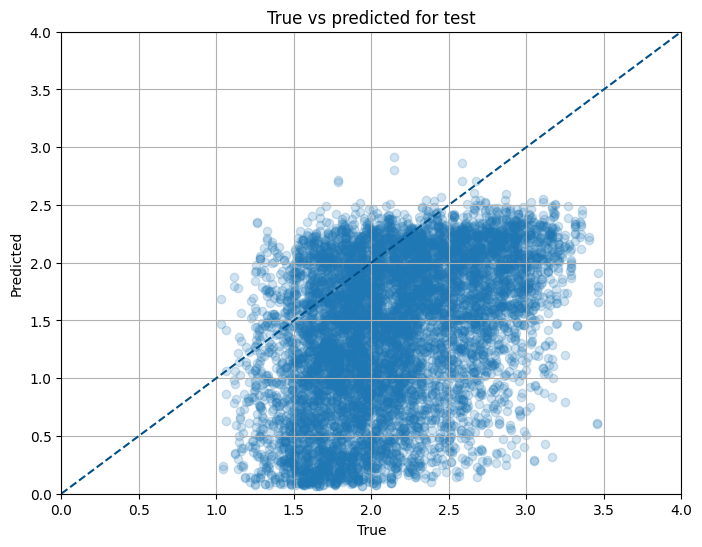

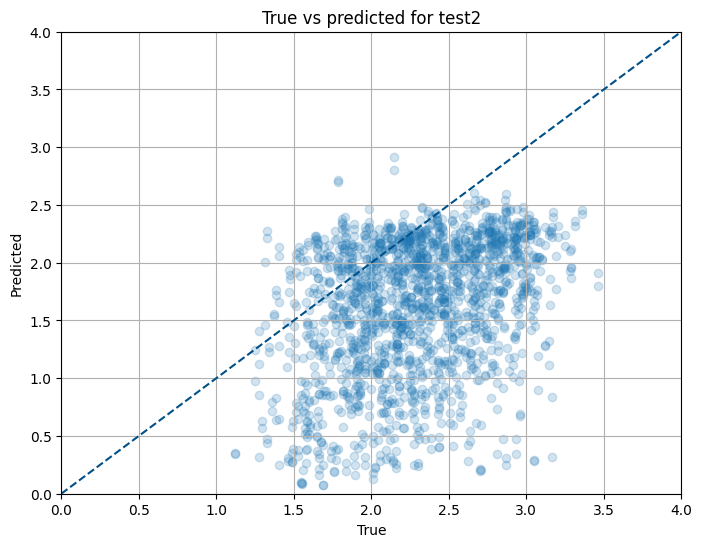

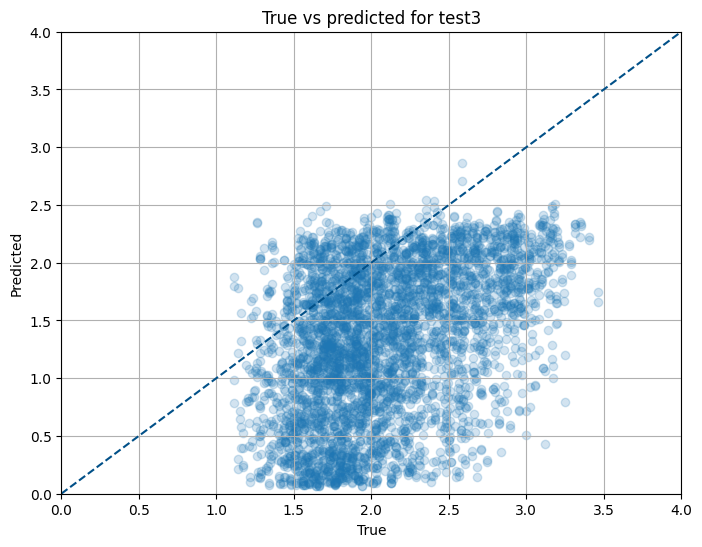

In [12]:
def scatter(pred_df, true_df, title, xlabel, ylabel):
    x = true_df.squeeze()
    y = pred_df.squeeze() 
    
    plt.figure(figsize=(8, 6))
    plt.xlim(0, 4)
    plt.ylim(0, 4)
    plt.plot([0, 4], [0, 4], color='#015088', linestyle='--', label='y = x')
    # plt.gcf().set_facecolor('#f3f0dfff')
    # plt.gca().set_facecolor('#f3f0dfff')
    plt.scatter(x, y, alpha=0.2)
    plt.xlabel(f'{xlabel}')
    plt.ylabel(f'{ylabel}')
    plt.title(f'{title}')
    plt.grid(True)
    plt.show()

def plotscatter():
    scatter(pred_testPos, doubled_testPos, 'True vs predicted for test', 'True', 'Predicted')
    scatter(pred_test2_df, doubled_test2_df, 'True vs predicted for test2', 'True', 'Predicted')
    scatter(pred_test3_df, doubled_test3_df, 'True vs predicted for test3', 'True', 'Predicted')
plotscatter()

In [14]:
# EXAMPLE MAKE ONE_TO_ONE_PEAKS THEN SAVE IT
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

species = 'newRat'

both_df = pd.read_csv(f"/home/azstephe/liverRegression/regression_liver/data/mapped/newRatToMouse_liver_ratEnhancer_mouseEnhancer_wawb.narrowPeak", sep="\t", header=None)
mac_qn = pd.read_csv(f"/home/azstephe/data/log_transformed/{species}_liver_pos_ALL.narrowPeak", sep="\t", header=None)
mouse_qn = pd.read_csv("/home/azstephe/liverRegression/regression_liver/data/log/mouse_liver_pos_ALL.bed", sep="\t", header=None)

unique1_2 = both_df[~both_df.duplicated(subset=[1, 2], keep=False)] # entries with unique mac mapped to mouse start and end
all_unique = unique1_2[~unique1_2.duplicated(subset=[11,12], keep=False)]

#### FUNCTIONS

def pearson_spearman(x, y):
    pearson_corr, pearson_p_value = scipy.stats.pearsonr(x, y)
    print(f"Pearson correlation coefficient: {pearson_corr:.4f}, p-value: {pearson_p_value:.4g}")

    spearman_corr, spearman_p_value = scipy.stats.spearmanr(x, y)
    print(f"Spearman correlation coefficient: {spearman_corr:.4f}, p-value: {spearman_p_value:.4g}")
    
def collapse_if_identical(lst):
    return lst[0] if all(x == lst[0] for x in lst) else lst
    

# takes in list and returns peak with largest signal
def keep_largest_signal(lst, qn_df):
    if isinstance(lst, list):
        maxPeakName = ''
        maxPeakStrength = 0
        for peak in lst:
            matching_rows = qn_df[qn_df[3] == peak]
            if not matching_rows.empty:
                signal = matching_rows[4].iloc[0]
                if signal > maxPeakStrength:
                    maxPeakStrength = signal
                    maxPeakName = peak
        return maxPeakName
    else: 
        return lst

# def overlap(start1, end1, start2, end2):
#     return max(0, min(end1, end2)-max(start1, start2))

def get_biggest_overlap(lst, col, df):
    maxOverlap = 0
    maxPeakOverlap = ""
    for peak in lst:
        row = df[df[col] == peak].iloc[0] #iloc bc possible to return multiple rows (never will based on th
        overlap = max(0, min(row[2], row[12])-max(row[1], row[11]))
        if overlap > maxOverlap:
            maxOverlap = overlap
            maxPeakOverlap = peak
    return peak

#### COL1,2 DUPLICATES

duplicates3 = both_df[both_df.duplicated(subset=[1, 2], keep=False)] # entries with duplicated mac mapped to mouse start and end 
grouped_dups3 = duplicates3.groupby([1, 2])[3].apply(list).reset_index(name='col3')

# grouped dups: start | end | [peaks with these endpoints]
grouped_dups3['col3'] = grouped_dups3['col3'].apply(collapse_if_identical) 

grouped_dups3['col3'] = grouped_dups3['col3'].apply(lambda x: keep_largest_signal(x, mac_qn)) # redundant endpoints now map to 1 peak in col3
grouped_dups3 = grouped_dups3[grouped_dups3['col3'] != ''] # remove macaque peaks that aren't large enough

# df of duplicated col1,2 with strongest peak
keep_strongestcol3 = duplicates3.merge(grouped_dups3[['col3']], left_on=3, right_on='col3', how='inner').drop('col3', axis=1) # keeps the strongest signal in col3 for redundant endpoints

#### COL11,12 DUPLICATES

grouped_dups13 = keep_strongestcol3.groupby([11, 12])[13].apply(list).reset_index(name='col13')
grouped_dups13['col13'] = grouped_dups13['col13'].apply(collapse_if_identical)

grouped_dups13['col13'] = grouped_dups13['col13'].apply(lambda x: keep_largest_signal(x, mouse_qn))
grouped_dups13 = grouped_dups13[grouped_dups13['col13'] != '']

keep_strongestcol13 = keep_strongestcol3.merge(grouped_dups13[['col13']], left_on=13, right_on='col13', how='inner').drop('col13', axis=1)

unique_endpoints = keep_strongestcol13 #rows with unique endpoints from the duplicated endpoints set

####

# col3 peakname duplicates with different endpoints
still_dups_col3 = unique_endpoints[unique_endpoints.duplicated(subset=[3], keep=False)]

# col3peaks | [col13 peaks intersecting col3 peak]
grouped_dcol3 = still_dups_col3.groupby(3)[13].apply(list).reset_index(name='col13')

# get the col13 peak with most overlap of col3
grouped_dcol3['col13'] = grouped_dcol3['col13'].apply(lambda x: get_biggest_overlap(x, 13, still_dups_col3))

merged3 = still_dups_col3.merge(grouped_dcol3[[3, 'col13']], left_on=[3, 13], right_on=[3, 'col13'], how='left', indicator=True)

remove3 = merged3[merged3['_merge'] == 'left_only'].drop(columns=['_merge']) # col13 is what we want to remove

unique_endpoints_subset = unique_endpoints.iloc[:,:20]
remove3_subset = remove3.iloc[:,:20]

# all col3 entries unique
unique3 = unique_endpoints[~unique_endpoints_subset.apply(tuple, axis=1).isin(remove3_subset.apply(tuple, axis=1))] 

####

# col13 peakname duplicates with different endpoints
still_dups_col13 = unique3[unique3.duplicated(subset=[13], keep=False)]

# col13peaks | [col3 peaks intersecting col13 peak]
grouped_dcol13 = still_dups_col13.groupby(13)[3].apply(list).reset_index(name='col3')

# get the col3 peak with most overlap of col13
grouped_dcol13['col3'] = grouped_dcol13['col3'].apply(lambda x: get_biggest_overlap(x, 3, still_dups_col13))

merged13 = still_dups_col13.merge(grouped_dcol13[[13, 'col3']], left_on=[3, 13], right_on=['col3', 13], how='left', indicator=True)

remove13 = merged13[merged13['_merge'] == 'left_only'].drop(columns=['_merge'])

unique3_subset = unique3.iloc[:, :20]
remove13_subset = remove13.iloc[:, :20]

# Identify rows in u3 that are NOT in remove3
filtered_peaks_unique = unique3[~unique3_subset.apply(tuple, axis=1).isin(remove13_subset.apply(tuple, axis=1))]

full_unique = pd.concat([all_unique, filtered_peaks_unique])

# Sort by column '1'
one_to_one_peaks = full_unique.sort_values(by=1).reset_index(drop=True)
one_to_one_peaks.to_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/oneToOnePeaks/{species}_mouse.bed', header=None, sep='\t')
one_to_one_peaks
##############################



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,chr2,3228518,3229410,peak12647,-1,.,-1,-1,-1,726,chr2,3228532,3229401,peak11427,1000,.,16.72388,152.95140,149.78862,727
1,chr1,3448175,3448616,peak23768,-1,.,-1,-1,-1,152,chr1,3448178,3448616,peak6,1000,.,5.69142,28.80574,26.32341,171
2,chr1,3551160,3551724,peak23763,-1,.,-1,-1,-1,408,chr1,3551249,3552129,peak14,486,.,4.07427,24.92339,22.48687,402
3,chr1,3611134,3611612,peak23761,-1,.,-1,-1,-1,270,chr1,3611136,3611701,peak19,1000,.,20.61240,259.11868,255.63828,261
4,chr2,3672520,3673254,peak12644,-1,.,-1,-1,-1,308,chr2,3672789,3673297,peak11433,1000,.,7.55882,44.43972,41.81209,375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,chr1,194962161,194962669,peak7519,-1,.,-1,-1,-1,242,chr1,194962063,194962515,peak1962,1000,.,9.16506,60.89205,58.14869,317
846,chr1,194995052,194995633,peak7523,-1,.,-1,-1,-1,345,chr1,194995180,194995620,peak1965,1000,.,8.09555,68.96048,66.16955,196
847,chr1,195014156,195014783,peak7526,-1,.,-1,-1,-1,483,chr1,195014253,195014589,peak1966,941,.,4.05203,25.33601,22.89649,132
848,chr1,195016571,195017542,peak7527,-1,.,-1,-1,-1,356,chr1,195017180,195017466,peak1968,1000,.,5.09901,40.06577,37.47466,169


In [17]:
# 1 3 5 BEST LOG MODELS FOLDCHANGE
import pandas as pd
import scipy.stats

def correlate(mhc):
    rows = []
    # Lists for correlation calculations
    groups = ['Test2']
    dfs = [test2_foldchange_df]

    # Calculate correlations
    for group, df in zip(groups, dfs):
        x = df['true'].squeeze()
        y = df['pred'].squeeze()
        pearson, pp = scipy.stats.pearsonr(x, y)
        spearman, ps = scipy.stats.spearmanr(x, y)

        mse = mean_squared_error(x, y)
        
        same_sign = np.sign(df['true']) == np.sign(df['pred'])
        num_ss = same_sign.sum()
        len_ss = len(df)
        perc_ss = num_ss / len_ss
        
        same_sign_avg = np.sign(df.loc[::2]['true']) == np.sign(df.loc[::2]['avg_pred'])
        num_ssa = same_sign_avg.sum()
        len_ssa = len(df) / 2
        perc_ssa = num_ssa / len_ssa
        
        rows.append({'Group': group, 'Metric': 'Same Sign Count', 'Value': num_ss})
        rows.append({'Group': group, 'Metric': 'Total Count', 'Value': len_ss})
        # print(f'total count: {len_ss}')
        rows.append({'Group': group, 'Metric': 'Same Sign %', 'Value': perc_ss})
     
        rows.append({'Group': group, 'Metric': 'Pearson', 'Value': pearson})
        rows.append({'Group': group, 'Metric': 'Pearson P-Val', 'Value': pp*mhc})
        rows.append({'Group': group, 'Metric': 'Spearman', 'Value': spearman})
        rows.append({'Group': group, 'Metric': 'Spearman P-Val', 'Value': ps*mhc})

        rows.append({'Group': group, 'Metric': 'MSE', 'Value': mse})
        
    return pd.DataFrame(rows)

# --- Main Script ---
all_results = []
species_list = ['newRat']
model_list = ['bdbi7l3n', 'kf8188qf', 'p1bd3srf', 'cq45eb2s']

for species in species_list:
    for model in model_list:
        mhc = 200
        if model == 'kf8188qf':
            mhc = 100
        model_dir = f'{model}'

        nonMouse_true = pd.read_csv(f'/home/azstephe/data/log_transformed/{species}_liver_pos_ALL.narrowPeak', sep="\t", header=None)
        mouse_true = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/log/mouse_liver_pos_ALL.bed', sep="\t", header=None)
        one_to_one_peaks_TEST = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/oneToOnePeaks/{species}_mouse.bed', header=None, sep='\t')


        #############################################################################
        # TIME FOR TEST2 FOLDCHANGE

        peaks = one_to_one_peaks_TEST[[4, 14]]

        merged_df = peaks.merge(nonMouse_true, how='left', left_on=4, right_on=3, suffixes=('', '_non'))
        
        # Aligned orthologous peaks
        merged_df = merged_df.merge(mouse_true, how='left', left_on=14, right_on=3, suffixes=('_NON', '_mouse'))

        #############################################################################
        
        # load MOUSE TEST DF

        pred_mouse_TEST = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/model_outputs/{model_dir}_FINAL/activations_mouse_TEST.csv', header=None)
        
        mouse_test = pd.read_csv('/home/azstephe/liverRegression/regression_liver/data/test_splits/log_pos/mouse_liver_TEST_500bp.bed', sep="\t", header=None)
        
        mouse_test_len = 2*len(mouse_test)

        doubled_mouse_test_df = pd.concat([mouse_test, mouse_test]).sort_index(kind='mergesort').reset_index(drop=True)
        doubled_mouse_test_df = doubled_mouse_test_df.rename(columns={0:'mouse_chr'})
    
        pred_mouse_test_df = pred_mouse_TEST.head(mouse_test_len).reset_index(drop=True)
        pred_mouse_test_df = pd.concat([doubled_mouse_test_df.drop(columns=5), pred_mouse_test_df], axis=1)
        pred_mouse_test_df = pred_mouse_test_df.rename(columns={4:'mouse_true', 0:'mouse_pred'}).reset_index(drop=True)
        
        merged_mouse_test_true_pred = peaks.merge(pred_mouse_test_df, how='left', left_on=14, right_on=3)
        mouse_test_true_pred = merged_mouse_test_true_pred.rename(columns={3:'mouse_peak'}).drop([14], axis=1)

        #############################################################################
        # load nonmouse TEST2 DF
        
        pred_TEST = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/model_outputs/{model_dir}/activations_{species}_TEST.csv', header=None)
        
        test1_df = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/test1/{species}_liver_TEST_500bp.bed', header=None, delim_whitespace=True).iloc[:,4]
        test2_df = pd.read_csv(f'/home/azstephe/liverRegression/regression_liver/data/test_splits/log_test2/{species}_liver_TEST_500bp.bed', header=None, delim_whitespace=True).rename(columns={0: 'mac_chr'})
        
        test1_len = 2*len(test1_df)
        test2_len = 2*len(test2_df)
        
        doubled_test2_df = pd.concat([test2_df, test2_df]).sort_index(kind='mergesort').reset_index(drop=True)
        pred_test2_df = pred_TEST.iloc[test1_len:test1_len + test2_len].reset_index(drop=True)
        doubled_test2_combined = pd.concat([doubled_test2_df, pred_test2_df], axis=1)

        non_test2_true_pred = doubled_test2_combined.rename(columns={4: 'non_true', 0:'non_pred'})
        merged_non_test2_true_pred = peaks.merge(non_test2_true_pred, how='left', left_on=4, right_on=3).drop(14, axis=1)
        non_test2_true_pred = merged_non_test2_true_pred.rename(columns={3:'non_peak'}).drop(4, axis=1)

        #############################################################################

        # make TEST2 merged df
        test2_foldchange_df = pd.concat([mouse_test_true_pred, non_test2_true_pred], axis=1)
        
        test2_foldchange_df['true'] = test2_foldchange_df['mouse_true']-test2_foldchange_df['non_true']
        test2_foldchange_df['pred'] = test2_foldchange_df['mouse_pred']-test2_foldchange_df['non_pred']
        
        mouse_av = (test2_foldchange_df.loc[::2, 'mouse_pred'].values + test2_foldchange_df.loc[1::2, 'mouse_pred'].values) / 2
        non_av = (test2_foldchange_df.loc[::2, 'non_pred'].values + test2_foldchange_df.loc[1::2, 'non_pred'].values) / 2
        
        # Add the averages back to the DataFrame as a new column
        test2_foldchange_df.loc[::2, 'mouse_pred_avg'] = mouse_av
        test2_foldchange_df.loc[::2, 'non_pred_avg'] = non_av 
        test2_foldchange_df['avg_pred'] = test2_foldchange_df['mouse_pred_avg']-test2_foldchange_df['non_pred_avg']
        
        corr_df = correlate(mhc)
        corr_df['Species'] = species
        corr_df['model'] = model
        all_results.append(corr_df)
        


#############################################################################

summary_df = pd.concat(all_results)

custom_group_order = [ 'Test2' ]
custom_metric_order = ['Same Sign Count', 'Total Count', 'Same Sign %', 'Pearson', 'Pearson P-Val', 'Spearman', 'Spearman P-Val', 'MSE']

# # Convert 'group' to a categorical type with the specified order.
summary_df['Group'] = pd.Categorical(summary_df['Group'], categories=custom_group_order, ordered=True)
summary_df['Metric'] = pd.Categorical(summary_df['Metric'], categories=custom_metric_order, ordered=True)


pivot_df = summary_df.pivot_table(
    index=["Species", "Group", "Metric"],
    columns="model",
    values="Value"
).reset_index()

pivot_df = pivot_df.sort_values(by=["Species", "Group", "Metric"])

pivot_df = pivot_df[["Species", "Group", "Metric"] + model_list]
# pivot_df_reordered = pivot_df[model_list]

def format_value(metric, value):
    """Format values depending on whether it's a P-Val metric or not."""
    if "P-Val" in metric:
        return f"{value:.2e}"   # scientific notation, 3 sig figs
    else:
        return f"{value:.3g}"   # regular decimal, 3 sig figs

# Apply formatting to a copy just for display/export
pivot_df_display = pivot_df.copy()
for col in model_list:  # each model column
    pivot_df_display[col] = pivot_df_display.apply(
        lambda row: format_value(row["Metric"], row[col]),
        axis=1
    )

display(pivot_df_display)

# output_filename = '/home/azstephe/liverRegression/regression_liver/data/figs/tables/135log_model_foldchange_table_FINAL_mse.tsv'
# pivot_df_display.to_csv(output_filename, sep='\t')

# print(f'Results successfully saved to: {output_filename}')


model,Species,Group,Metric,bdbi7l3n,kf8188qf,p1bd3srf,cq45eb2s
0,newRat,Test2,Same Sign Count,928,1e+03,988,997
1,newRat,Test2,Total Count,1.7e+03,1.7e+03,1.7e+03,1.7e+03
2,newRat,Test2,Same Sign %,0.546,0.591,0.581,0.586
3,newRat,Test2,Pearson,0.16,0.244,0.222,0.24
4,newRat,Test2,Pearson P-Val,6.99e-09,1.77e-22,4.39e-18,2.04e-21
5,newRat,Test2,Spearman,0.156,0.258,0.215,0.247
6,newRat,Test2,Spearman P-Val,2.07e-08,3.38e-25,5.25e-17,9.10e-23
7,newRat,Test2,MSE,0.294,0.492,0.419,0.433


In [18]:
pivot_neg_df_reordered

model                                      bdbi7l3n  kf8188qf  p1bd3srf  \
species Group          Metric                                             
newRat  Test neg       Avg Neg Prediction  0.634165  0.449816  0.508343   
        Test1 avg pred Avg Neg Prediction  0.673352  0.563940  0.621655   

model                                      cq45eb2s  
species Group          Metric                        
newRat  Test neg       Avg Neg Prediction  0.428777  
        Test1 avg pred Avg Neg Prediction  0.545266